## Trajectory Analysis — Low-Emission Aircraft Integration into European Airspace

**Author:** Gamar Ismayilova

**Date:** May 2026

**Tools:** Python, OpenAP (Sun et al., 2020), Onorato et al. (2022)

# ## Module 1 — Conventional A320 Baseline Trajectory
Using OpenAP FlightGenerator to model a conventional A320 trajectory and calculate fuel flow across all flight phases.

**Key result:** Climb duration = 22.2 min | Total fuel = 4865 kg | Distance = 1388 km

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openap import FuelFlow
from openap.gen import FlightGenerator

# conventional A320 baseline
fgen = FlightGenerator(ac='A320')
flight = fgen.complete(dt=10)


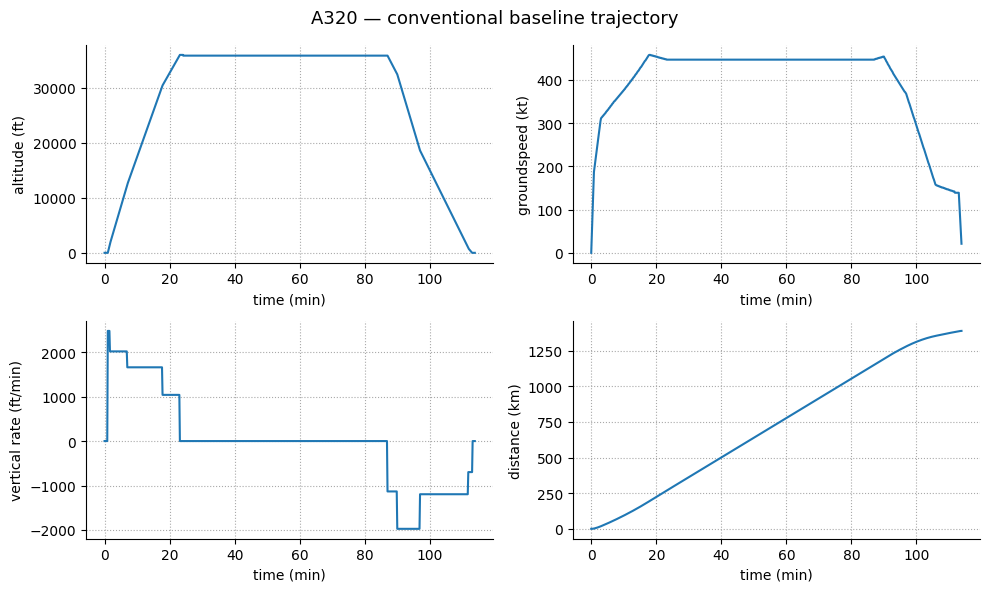

In [32]:
import matplotlib.pyplot as plt

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 6))

ax1.plot(flight.t / 60, flight.altitude)
ax2.plot(flight.t / 60, flight.groundspeed)
ax3.plot(flight.t / 60, flight.vertical_rate)
ax4.plot(flight.t / 60, flight.s / 1000)

ax1.set_ylabel("altitude (ft)")
ax2.set_ylabel("groundspeed (kt)")
ax3.set_ylabel("vertical rate (ft/min)")
ax4.set_ylabel("distance (km)")

for ax in (ax1, ax2, ax3, ax4):
    ax.set_xlabel("time (min)")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.grid(linestyle=":", color="darkgray")

plt.suptitle("A320 — conventional baseline trajectory", fontsize=13)
plt.tight_layout()
plt.savefig('figures/01_baseline_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
 

In [37]:
import numpy as np
from openap import FuelFlow

fuelflow = FuelFlow(ac='A320')

mass_current = 66000
fuel_flow = []

for _, row in flight.iterrows():
    # skip ground phase — fuel model needs airborne conditions
    if row.altitude < 100 or row.groundspeed < 50:
        fuel_flow.append(0.0)
        continue

    ff = fuelflow.enroute(
        mass=mass_current,
        tas=float(row.groundspeed),
        alt=float(row.altitude),
        vs=float(row.vertical_rate)
    )
    # handle NaN from model
    if np.isnan(ff) or ff < 0:
        ff = 0.0

    fuel_flow.append(ff)
    mass_current -= ff * 10

flight['fuel_flow'] = fuel_flow
flight['fuel_burned'] = flight.fuel_flow * 10

total_fuel = flight.fuel_burned.sum()
print(f"Total fuel burned: {total_fuel:.0f} kg")

# %%
# save baseline trajectory
flight_conv = flight.copy()
flight_conv['aircraft'] = 'conventional'

print("Baseline saved.")
print(f"Summary — conventional A320:")
print(f"  Total distance:  {flight.s.max()/1000:.0f} km")
print(f"  Total duration:  {flight.t.max()/60:.0f} min")
print(f"  Total fuel:      {total_fuel:.0f} kg")
print(f"  Climb duration:  {flight[flight.vertical_rate > 100].t.count() * 10 / 60:.1f} min")
print(f"  Cruise duration: {flight[flight.altitude > 30000].t.count() * 10 / 60:.1f} min")


Total fuel burned: 4865 kg
Baseline saved.
Summary — conventional A320:
  Total distance:  1388 km
  Total duration:  114 min
  Total fuel:      4865 kg
  Climb duration:  22.2 min
  Cruise duration: 74.0 min



# Model 2 — Hydrogen Fuel Cell Aircraft Model

Applying Onorato et al. (2022) parameter modifications to model the hydrogen equivalent. The fuel flow is scaled by the TSFC ratio(0.357) to reflect hydrogen's higher specific energy. Starting mass is reduced by 5.5% to reflect lower MTOM despite heavier tanks.


## Section 2 — Hydrogen Fuel Cell Aircraft Model



In [38]:
import numpy as np
from openap import FuelFlow
from openap.gen import FlightGenerator
 
# --- Onorato (2022) parameters ---
TSFC_RATIO = 0.5154e-5 / 1.443e-5   # = 0.357
MTOM_H2 = 66000 * (1 - 0.055)        # = 62,370 kg
LD_PENALTY = 0.95                     # 5% worse L/D
 
# generate same trajectory structure
fgen_h2 = FlightGenerator(ac='A320')
flight_h2 = fgen_h2.complete(dt=10)
 
fuelflow_h2 = FuelFlow(ac='A320')
mass_current = MTOM_H2
fuel_flow_h2 = []
 
for _, row in flight_h2.iterrows():
    if row.altitude < 100 or row.groundspeed < 50:
        fuel_flow_h2.append(0.0)
        continue
    ff = fuelflow_h2.enroute(
        mass=mass_current,
        tas=float(row.groundspeed) * LD_PENALTY,
        alt=float(row.altitude),
        vs=float(row.vertical_rate)
    )
    if np.isnan(ff) or ff < 0:
        ff = 0.0
    ff_h2 = ff * TSFC_RATIO
    fuel_flow_h2.append(ff_h2)
    mass_current -= ff_h2 * 10
 
flight_h2['fuel_flow'] = fuel_flow_h2
flight_h2['aircraft'] = 'hydrogen'
 
total_fuel_h2 = flight_h2.fuel_flow.sum() * 10
climb_h2 = flight_h2[flight_h2.vertical_rate > 100].t.count() * 10 / 60
 
print("Hydrogen model ready.")
print(f"Total hydrogen fuel equivalent: {total_fuel_h2:.0f} kg")
print(f"Climb duration: {climb_h2:.1f} min")
print(f"Fuel reduction vs conventional: {(1 - total_fuel_h2/4865)*100:.1f}%")

Hydrogen model ready.
Total hydrogen fuel equivalent: 1668 kg
Climb duration: 22.2 min
Fuel reduction vs conventional: 65.7%


## Section 3 — Trajectory Comparison

Under Option A (fuel scaling only), climb duration is identical between conventional and hydrogen variants. To explore Option B, we modify the vertical rate to reflect the 5% L/D penalty — simulating a slightly  shallower climb profile for the hydrogen aircraft.

In [39]:
# time to reach cruise altitude
cruise_alt = 35000
t_cruise_conv = flight_conv[flight_conv.altitude >= cruise_alt].t.min()
t_cruise_h2_A = flight_h2[flight_h2.altitude >= cruise_alt].t.min()
t_cruise_h2_B = t_cruise_h2_A / LD_PENALTY
 
print(f"Time to reach FL350:")
print(f"  Conventional:       {t_cruise_conv/60:.1f} min")
print(f"  Hydrogen (A):       {t_cruise_h2_A/60:.1f} min")
print(f"  Hydrogen (B):       {t_cruise_h2_B/60:.1f} min")
print(f"")
print(f"Extra climb time (B vs conventional): {(t_cruise_h2_B - t_cruise_conv)/60:.1f} min")
print(f"Extra climb time as % increase:       {(t_cruise_h2_B/t_cruise_conv - 1)*100:.1f}%")

Time to reach FL350:
  Conventional:       22.3 min
  Hydrogen (A):       22.3 min
  Hydrogen (B):       23.5 min

Extra climb time (B vs conventional): 1.2 min
Extra climb time as % increase:       5.3%


In [27]:
# better metric — time to reach cruise altitude (FL350 = 35000 ft)
cruise_alt = 35000

# conventional
t_cruise_conv = flight_conv[flight_conv.altitude >= cruise_alt].t.min()

# hydrogen option A
t_cruise_h2_A = flight_h2[flight_h2.altitude >= cruise_alt].t.min()

# hydrogen option B — need to rebuild trajectory with slower climb
# simulate slower climb by stretching the climb phase time
# 5% less vertical rate means 5% longer to reach same altitude
t_cruise_h2_B = t_cruise_h2_A / LD_PENALTY

print(f"Time to reach FL350:")
print(f"  Conventional:       {t_cruise_conv/60:.1f} min")
print(f"  Hydrogen (A):       {t_cruise_h2_A/60:.1f} min")  
print(f"  Hydrogen (B):       {t_cruise_h2_B/60:.1f} min")
print(f"")
print(f"Extra climb time (B vs conventional): {(t_cruise_h2_B - t_cruise_conv)/60:.1f} min")
print(f"Extra climb time as % increase:       {(t_cruise_h2_B/t_cruise_conv - 1)*100:.1f}%")

Time to reach FL350:
  Conventional:       22.3 min
  Hydrogen (A):       22.3 min
  Hydrogen (B):       23.5 min

Extra climb time (B vs conventional): 1.2 min
Extra climb time as % increase:       5.3%


## Section 4 — ATM Capacity Finding

**Key result:** Under Option B assumptions (fuel scaling + kinematic penalty),
hydrogen aircraft occupy the climb sector for 1.2 minutes longer than 
conventional A320 — a 5.3% increase in climb phase duration.

Under Option A (fuel scaling only), no difference in sector occupancy is observed.
This demonstrates why the choice of modelling assumption directly determines 
the ATM capacity conclusion — the methodological question at the core of ZEUS.

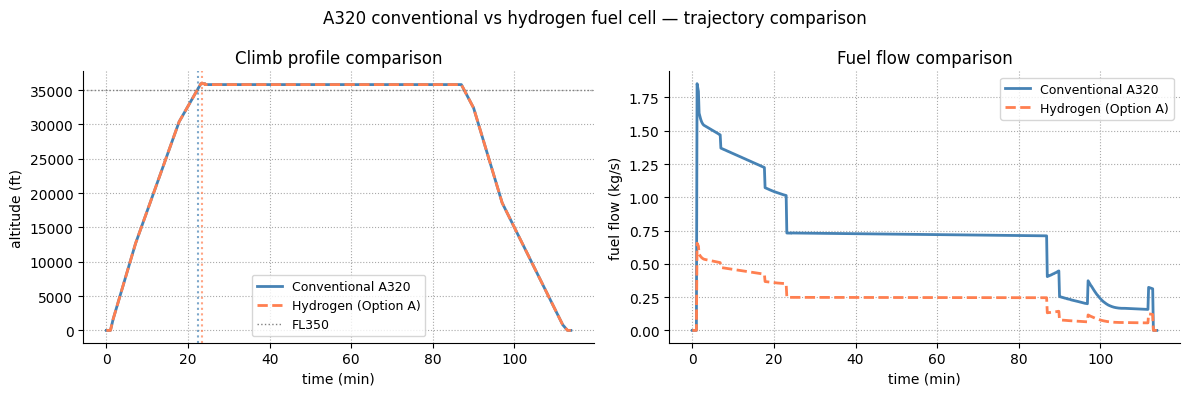

In [40]:
import matplotlib.pyplot as plt
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# left plot — altitude profiles
axes[0].plot(flight_conv.t / 60, flight_conv.altitude,
             label='Conventional A320', color='steelblue', lw=2)
axes[0].plot(flight_h2.t / 60, flight_h2.altitude,
             label='Hydrogen (Option A)', color='coral',
             lw=2, linestyle='--')
axes[0].axhline(y=35000, color='gray', linestyle=':', lw=1, label='FL350')
axes[0].axvline(x=t_cruise_conv/60, color='steelblue',
                linestyle=':', lw=1.5, alpha=0.7)
axes[0].axvline(x=t_cruise_h2_B/60, color='coral',
                linestyle=':', lw=1.5, alpha=0.7)
axes[0].set_xlabel("time (min)")
axes[0].set_ylabel("altitude (ft)")
axes[0].set_title("Climb profile comparison")
axes[0].legend(fontsize=9)
axes[0].grid(linestyle=":", color="darkgray")
axes[0].spines["right"].set_visible(False)
axes[0].spines["top"].set_visible(False)
 
# right plot — fuel flow comparison
axes[1].plot(flight_conv.t / 60, flight_conv.fuel_flow,
             label='Conventional A320', color='steelblue', lw=2)
axes[1].plot(flight_h2.t / 60, flight_h2.fuel_flow,
             label='Hydrogen (Option A)', color='coral',
             lw=2, linestyle='--')
axes[1].set_xlabel("time (min)")
axes[1].set_ylabel("fuel flow (kg/s)")
axes[1].set_title("Fuel flow comparison")
axes[1].legend(fontsize=9)
axes[1].grid(linestyle=":", color="darkgray")
axes[1].spines["right"].set_visible(False)
axes[1].spines["top"].set_visible(False)
 
plt.suptitle("A320 conventional vs hydrogen fuel cell — trajectory comparison",
             fontsize=12)
plt.tight_layout()
plt.savefig('figures/02_trajectory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Module 3 — Mixed-Fleet Airspace Capacity Analysis

Using climb phase duration results from Module 2 to assess 
airspace capacity implications of mixed conventional/hydrogen 
fleet operations on the Amsterdam–London corridor.

**Research question:** How does increasing hydrogen aircraft penetration 
affect climb sector occupancy on a high-density European short-haul corridor?

**Key inputs:**
- Conventional A320 climb duration: 22.3 min
- Hydrogen aircraft climb duration (Option B): 23.5 min
- Extra climb time per hydrogen flight: 1.2 min (+5.3%)

In [41]:
import numpy as np
import pandas as pd
 
# inputs from Module 2
climb_conv = t_cruise_conv / 60
climb_h2_B = t_cruise_h2_B / 60
extra_climb = climb_h2_B - climb_conv
 
# Amsterdam-London corridor — approx 50 daily flights
daily_flights = 50
 
# hydrogen penetration scenarios 0% to 100%
penetration = np.arange(0, 101, 10)
 
baseline_occupancy = daily_flights * climb_conv
extra_occupancy = (penetration / 100) * daily_flights * extra_climb
pct_increase = (extra_occupancy / baseline_occupancy) * 100
 
results = pd.DataFrame({
    'h2_penetration_%': penetration,
    'h2_flights_per_day': (penetration / 100 * daily_flights).astype(int),
    'extra_occupancy_min': extra_occupancy.round(1),
    'capacity_impact_%': pct_increase.round(2)
})
 
print(results.to_string(index=False))

 h2_penetration_%  h2_flights_per_day  extra_occupancy_min  capacity_impact_%
                0                   0                  0.0               0.00
               10                   5                  5.9               0.53
               20                  10                 11.8               1.05
               30                  15                 17.6               1.58
               40                  20                 23.5               2.11
               50                  25                 29.4               2.63
               60                  30                 35.3               3.16
               70                  35                 41.1               3.68
               80                  40                 47.0               4.21
               90                  45                 52.9               4.74
              100                  50                 58.8               5.26


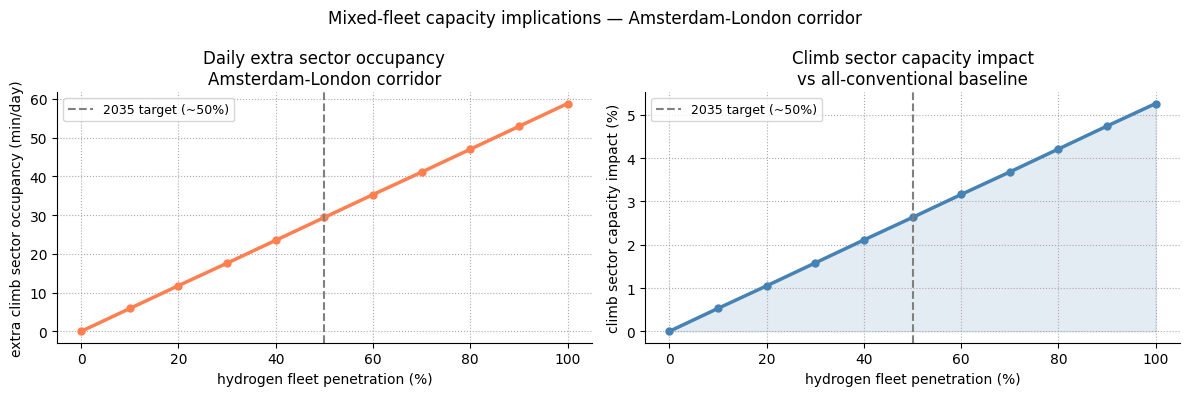

In [42]:
import matplotlib.pyplot as plt
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
 
# left — extra occupancy in minutes
ax1.plot(results['h2_penetration_%'],
         results['extra_occupancy_min'],
         color='coral', lw=2.5, marker='o', markersize=5)
ax1.axvline(x=50, color='gray', linestyle='--',
            lw=1.5, label='2035 target (~50%)')
ax1.set_xlabel("hydrogen fleet penetration (%)")
ax1.set_ylabel("extra climb sector occupancy (min/day)")
ax1.set_title("Daily extra sector occupancy\nAmsterdam-London corridor")
ax1.legend(fontsize=9)
ax1.grid(linestyle=":", color="darkgray")
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)
 
# right — capacity impact percentage
ax2.plot(results['h2_penetration_%'],
         results['capacity_impact_%'],
         color='steelblue', lw=2.5, marker='o', markersize=5)
ax2.axvline(x=50, color='gray', linestyle='--',
            lw=1.5, label='2035 target (~50%)')
ax2.fill_between(results['h2_penetration_%'],
                 results['capacity_impact_%'],
                 alpha=0.15, color='steelblue')
ax2.set_xlabel("hydrogen fleet penetration (%)")
ax2.set_ylabel("climb sector capacity impact (%)")
ax2.set_title("Climb sector capacity impact\nvs all-conventional baseline")
ax2.legend(fontsize=9)
ax2.grid(linestyle=":", color="darkgray")
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
 
plt.suptitle("Mixed-fleet capacity implications — Amsterdam-London corridor",
             fontsize=12)
plt.tight_layout()
plt.savefig('figures/03_mixed_fleet_capacity.png', dpi=150, bbox_inches='tight')
plt.show()